In [23]:
import pandas as pd
import numpy as np

# Load the features from Final_Features.csv
df = pd.read_csv("Extracted_Features.csv")

# Compute the correlation matrix
correlation_matrix = df.corr()

# Set a threshold for identifying highly correlated features
correlation_threshold = 0.9

# Create an upper triangle matrix of the correlation matrix
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Find features with correlation greater than the threshold
redundant_features = [
    column for column in upper_triangle.columns if any(upper_triangle[column].abs() > correlation_threshold)
]

# Drop the redundant features
reduced_df = df.drop(columns=redundant_features)

# Display the results
print(f"Number of features before removing redundancy: {df.shape[1]}")
print(f"Number of features after removing redundancy: {reduced_df.shape[1]}")
print(f"Removed features: {redundant_features}")

# Optionally save the reduced DataFrame
reduced_df.to_csv("Red_Features.csv", index=False)

Number of features before removing redundancy: 33
Number of features after removing redundancy: 27
Removed features: ['RMS', 'Total Power', 'Wavelet Energy Level 2', 'Wavelet Energy Level 4', 'Wavelet Energy Level 5', 'Instantaneous Amplitude Mean']


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the reduced dataset
reduced_df = pd.read_csv("Red_Features.csv")

# Assume the target column is named 'Target'
X = reduced_df.drop(columns=['Premature','RecID'])
y = reduced_df['Premature']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

# Initialize feature importance dictionaries
feature_importance_scores = {col: 0 for col in X.columns}

# Scale the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Random Forest Feature Importance
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
rf_scores = rf.feature_importances_

# Recursive Feature Elimination (RFE)
log_reg = LogisticRegression(max_iter=2000, solver='saga', random_state=42)  # Increase max_iter and change solver
rfe = RFE(log_reg, n_features_to_select=5)  # Set the desired number of features
rfe.fit(X_train_scaled, y_train)
rfe_scores = rfe.ranking_

# L1-Based Feature Selection
lasso = LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, random_state=42)  # Increase max_iter
lasso.fit(X_train_scaled, y_train)
lasso_scores = np.abs(lasso.coef_[0])

# Combine scores from all methods
combined_scores = (
    scaler.fit_transform(rf_scores.reshape(-1, 1)).flatten() +
    scaler.fit_transform(1 / rfe_scores.reshape(-1, 1)).flatten() +  # Inverse for ranking
    scaler.fit_transform(lasso_scores.reshape(-1, 1)).flatten()
)

# Map final scores to features
for feature, score in zip(X.columns, combined_scores):
    feature_importance_scores[feature] = score

# Sort features by importance
sorted_features = sorted(feature_importance_scores.items(), key=lambda x: x[1], reverse=True)


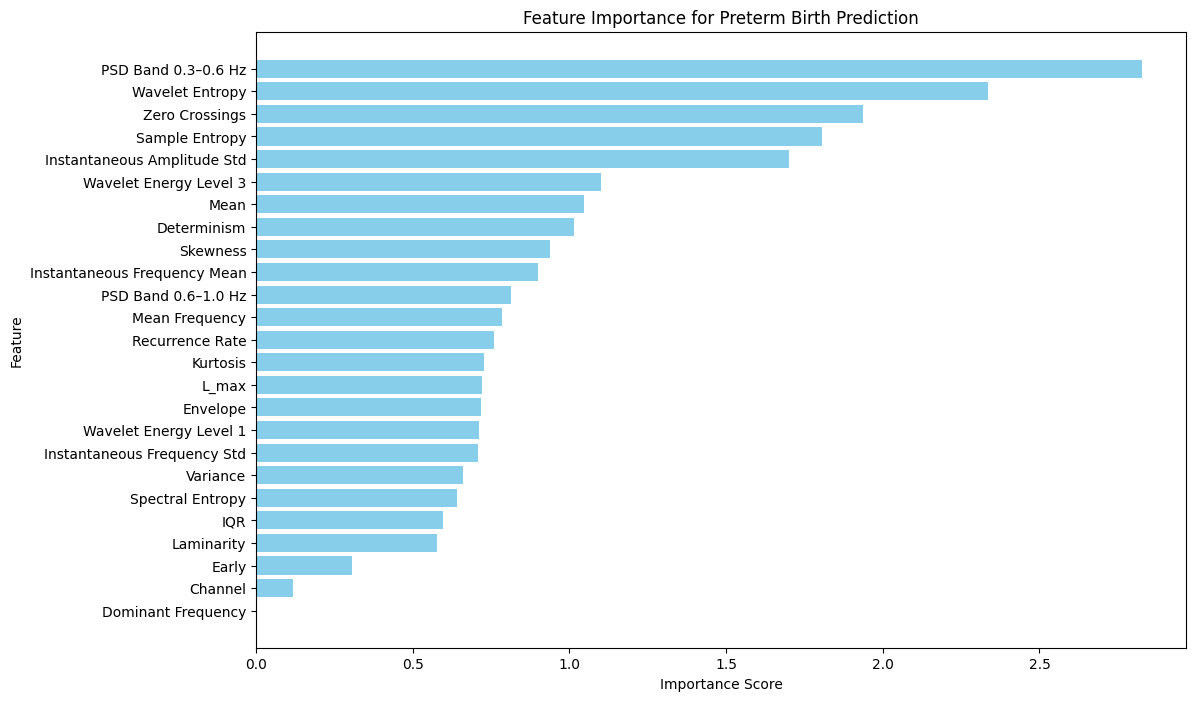

In [26]:
import matplotlib.pyplot as plt

# Convert to DataFrame for easy plotting
importance_df = pd.DataFrame(sorted_features, columns=['Feature', 'Importance'])

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance for Preterm Birth Prediction')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()


In [22]:
# Save the top N features
top_features = importance_df[importance_df['Importance'] > 0.5] # Adjust N as needed
top_features.to_csv("Top_Features.csv", index=False)

print("Top features saved to 'Top_Features.csv'.")


Top features saved to 'Top_Features.csv'.
